In [117]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_squared_error

## Question 1

In [2]:
#Linear regression with bias term included
X = np.array([[1,-10],
             [1,-8],
             [1,-3],
             [1,-1],
             [1,2],
             [1,8]])
y = np.array([[5],[5],[4],[3],[2],[2]])

#least square solution
w = np.linalg.inv(X.T @ X) @ X.T @ y
print("Estimated weights:", w)


Estimated weights: [[ 3.10550459]
 [-0.19724771]]


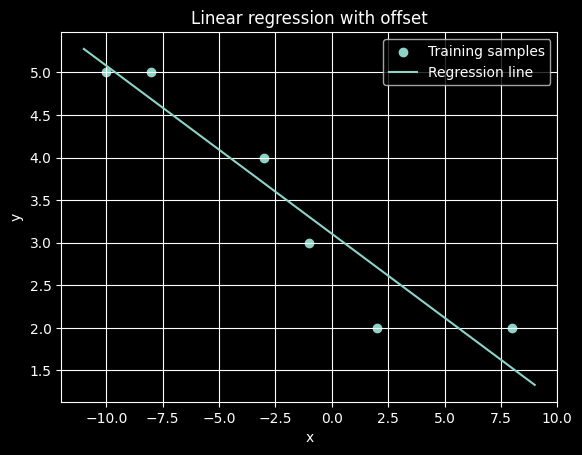

In [7]:
#Extract x values
x_val = X[:,1]
x_line = np.linspace(min(x_val)-1, max(x_val)+1, 100)
y_line = w[0] + w[1]*x_line
plt.scatter(x_val,y, label="Training samples")
plt.plot(x_line,y_line, label = "Regression line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear regression with offset")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
#Linear regression without bias term
X = np.array([[-10],
             [-8],
             [-3],
             [-1],
             [2],
             [8]])
y = np.array([[5],[5],[4],[3],[2],[2]])

#least square solution
w = np.linalg.inv(X.T @ X) @ X.T @ y
print("Estimated weights:", w)

Estimated weights: [[-0.35123967]]


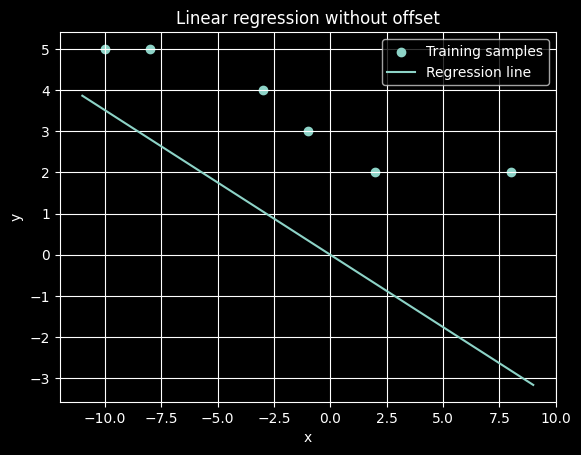

In [10]:
x_val = X[:,0]
x_line = np.linspace(min(x_val)-1, max(x_val)+1, 100)
y_line =w[0]*x_line
plt.scatter(x_val,y, label="Training samples")
plt.plot(x_line,y_line, label = "Regression line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear regression without offset")
plt.legend()
plt.grid(True)
plt.show()

The bias/offset term allows the line to move away from the origin.

Estimated weights with bias:
  [[ 3.10550459]
 [-0.19724771]]
Estimated weights without bias:
 [[-0.35123967]]


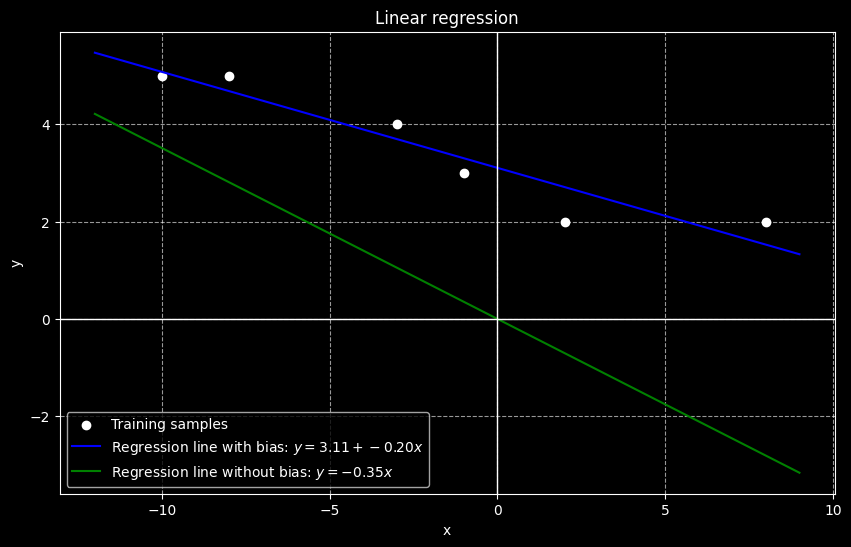

In [34]:
#Question 1 Combined

#Raw training data
X_raw = np.array([[-10],[-8],[-3],[-1],[2],[8]])
y = np.array([[5],[5],[4],[3],[2],[2]])

#Model with bias term included
X_bias = np.c_[np.ones(X_raw.shape[0]), X_raw]
w_bias = np.linalg.inv(X_bias.T @ X_bias)@ X_bias.T @ y #Overdetermined
print("Estimated weights with bias:\n ", w_bias)

#Model without bias term included
X_no_bias = X_raw
w_no_bias = np.linalg.inv(X_no_bias.T @ X_no_bias) @ X_no_bias.T @y #Overdetermined
print("Estimated weights without bias:\n", w_no_bias)

#Plot
x_line = np.linspace(min(X_raw)-2, max(X_raw)+1, 100)
y_line_bias = w_bias[0] + w_bias[1]*x_line
y_line_no_bias = w_no_bias[0]*x_line

plt.figure(figsize=(10,6))
plt.scatter(X_raw, y, label= "Training samples",color = "white")
plt.plot(x_line,y_line_bias, label= f"Regression line with bias: $y = {w_bias[0,0]:.2f} + {w_bias[1,0]:.2f}x$",color = "blue")
plt.plot(x_line,y_line_no_bias, label= f"Regression line without bias: $y = {w_no_bias[0,0]:.2f}x$",color = "green")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear regression")
plt.legend()
plt.grid(True,linestyle="--",alpha=0.6)
plt.axhline(0, color='white', lw=1)
plt.axvline(0, color='white', lw=1)
plt.show()

## Question 2

In [45]:
#Question 2(a)
X_raw = np.array([[1,0,1],
             [2,-1,1],
              [1,1,5]])
y = np.array([[1],
              [2],
              [3]])

#weights without bias
w_no_bias = np.linalg.inv(X_raw) @ y #Note: Even-determined system
print("Estimated weights without best:\n", w_no_bias)

X = np.c_[np.ones(X_raw.shape[0]), X_raw]
w_bias = X.T @ np.linalg.inv(X @ X.T) @ y #Note: Under-determined system
print("Estimated weights with bias:\n", w_bias)

X_test = np.array([[-1,2,8],
                   [1,5,-1]])
y_test_no_bias = X_test @ w
y_test_bias = np.c_[np.ones(X_test.shape[0]), X_test] @ w_bias #Include back the one

print("output without bias:\n", y_test_no_bias)
print("output with bias:\n", y_test_bias)

Estimated weights without best:
 [[ 0.33333333]
 [-0.66666667]
 [ 0.66666667]]
Estimated weights with bias:
 [[-0.14285714]
 [ 0.52380952]
 [-0.47619048]
 [ 0.61904762]]
output without bias:
 [[ 3.66666667]
 [-3.66666667]]
output with bias:
 [[ 3.33333333]
 [-2.61904762]]


## Question 3 

Regression coefficient:
 [[9.3       ]
 [0.67272727]]
y when x = 30:
 [29.48181818]
y when x = 5:
 [12.66363636]


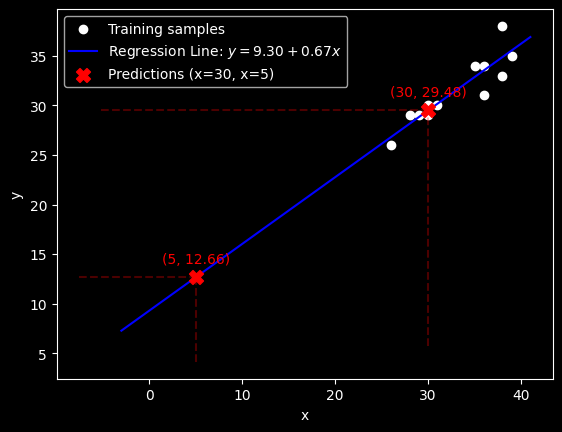

In [62]:
#Training data
X_raw = np.array([[36],[28],[35],[39],[30],[30],[31],[38],[36],[38],[29],[26]])
y = np.array([[31],[29],[34],[35],[29],[30],[30],[38],[34],[33],[29],[26]])

#Calculate regression coefficient
X_bias = np.c_[np.ones(X_raw.shape[0]), X_raw]
w = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ y #Overdetermined system

print("Regression coefficient:\n", w)

x_test = np.array([[1,30],[1,5]])
y_test =  x_test @ w
print("y when x = 30:\n", y_test[0])
print("y when x = 5:\n", y_test[1])

x_line = np.linspace(X_test.min()-2,X_raw.max()+2,100)
y_line = w[0] + w[1]*x_line
plt.scatter(X_raw, y, label= "Training samples", color = "white")
plt.plot(x_line,y_line, label= f"Regression Line: $y = {w[0,0]:.2f} + {w[1,0]:.2f}x$", color = "blue")

test_x_vals = x_test[:, 1]
test_y_vals = y_test.flatten()

# 3. Plot the specific test points
plt.scatter(test_x_vals, test_y_vals, color="red", marker="X", s=100, label="Predictions (x=30, x=5)", zorder=5)

for tx, ty in zip(test_x_vals, test_y_vals):
    plt.vlines(tx, plt.ylim()[0], ty, colors='red', linestyles='dashed', alpha=0.3)
    plt.hlines(ty, plt.xlim()[0], tx, colors='red', linestyles='dashed', alpha=0.3)
    plt.annotate(f'({tx}, {ty:.2f})', (tx, ty), textcoords="offset points", xytext=(0,10), ha='center', color='red')

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

Note:
* Prediction when x = 5 appears to be somewhat over optimistic.
* Since 5 students is not within the range of sampled number of students, it might not be appropriate to use the regression equation to make this prediciton.
* We do not know if the straight-line model would fit the data at this point, and we might not want to extrapolate far beyond the observed range.

## Question 4

Regression coefficient:
 [[-10.41257051]
 [  1.21434327]]
Prediction when x = 30:
 26.017727639000807
New prediction when x = 30: 
 27.220779220779125


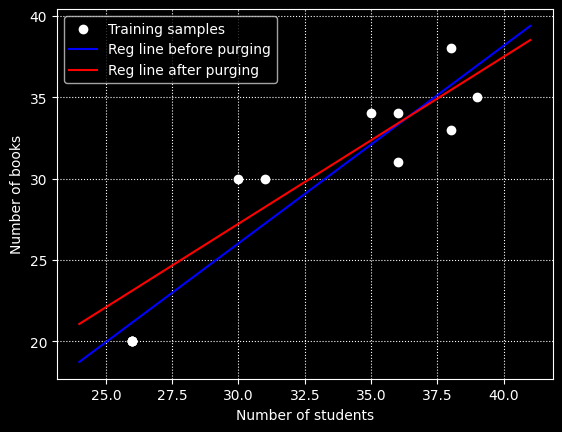

In [82]:
X_raw_1 = np.array([[36],[26],[35],[39],[26],[30],[31],[38],[36],[38],[26],[26]])
y = np.array([[31],[20],[34],[35],[20],[30],[30],[38],[34],[33],[20],[20]])

X_bias = np.c_[np.ones(X_raw_1.shape[0]), X_raw_1]
w = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ y #Overdetermined System

print("Regression coefficient:\n", w)

X_test = np.array([1,30])
y_pred = X_test @ w
print("Prediction when x = 30:\n", y_pred[0])

combined = np.hstack((X_raw_1, y)) #Combine X and y side by side
unique_data = np.unique(combined, axis=0) #Check for unique rows

X_purged = unique_data[:, 0:1] #Split X and Y
Y_purged = unique_data[:, 1:2]

X_purged_bias = np.c_[np.ones(X_purged.shape[0]), X_purged]
w_new = np.linalg.inv(X_purged_bias.T @ X_purged_bias) @ X_purged_bias.T @ Y_purged

y_pred_new = X_test @ w_new

print("New prediction when x = 30: \n", y_pred_new[0])

plt.scatter(X_raw_1, y, label="Training samples", color = "white")
x_line = np.linspace(X_raw_1.min()-2,X_raw.max()+2,100)
y_line_1 = w[0] + w[1]*x_line
y_line_2 = w_new[0] + w_new[1]*x_line
plt.plot(x_line, y_line_1, label="Reg line before purging", color="blue")
plt.plot(x_line, y_line_2, label="Reg line after purging", color="red")
plt.grid(True,linestyle = ':')
plt.xlabel("Number of students")
plt.ylabel("Number of books")
plt.legend()
plt.show()



Note:
* These results show that duplicating samples can influence the learning and decision too.
* In this case, purging seems to give a more optimistic prediction for a relatively small number of students (<37) and more conservative prediction for a relatively large number of students (>37).

# Question 5

Predicted expenditure in 2021: 12102904.270643115


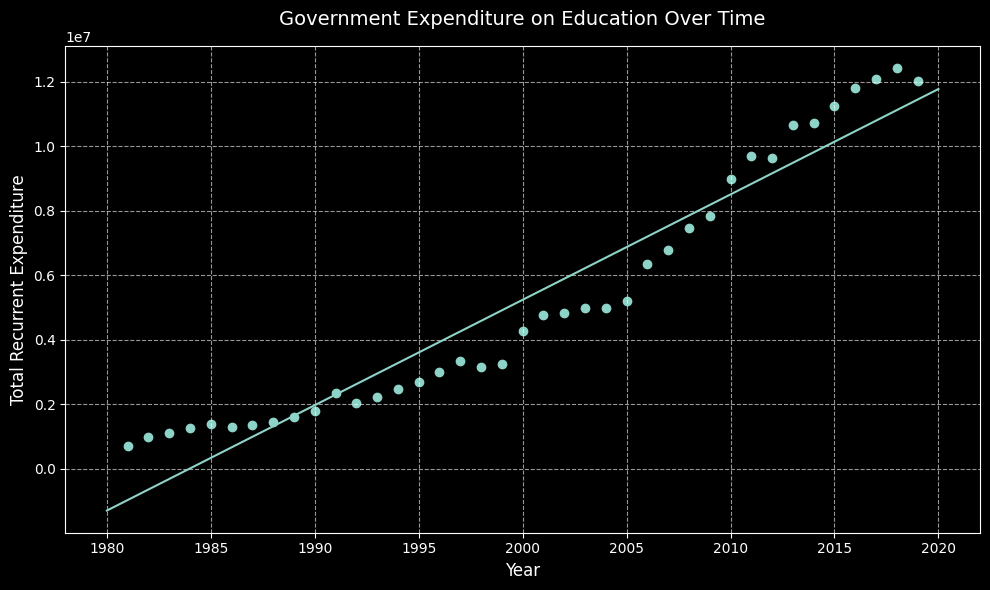

In [111]:
#import data frame
df = pd.read_csv("Tutorial 5 supp government-expenditure-on-education.csv")
expenditure_list = df['recurrent_expenditure_total'].tolist()
year_list = df['year'].tolist()
m_list = [[1] * len(year_list), year_list]

X = np.array(m_list).T
y = np.array(expenditure_list)

w = np.linalg.inv(X.T @ X) @ X.T @ y #over-determined
X_test = np.array([1,2021])
y_pred = X_test @ w
print("Predicted expenditure in 2021:",y_pred)

x_line = np.linspace(1980, 2020)
y_line = w[0] + w[1]*x_line

plt.figure(figsize=(10,6))
plt.scatter(year_list,expenditure_list)
plt.plot(x_line,y_line)
plt.title('Government Expenditure on Education Over Time', fontsize=14, pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Recurrent Expenditure', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Question 6

In [133]:
#get data
wine = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv",sep=';')
wine.info()
#y = wine.quality, x = wine.drop('quality', axis = 1)
y = wine.quality
x = wine.drop('quality', axis = 1) #Remove the quality column

#Including offset term
x0 = np.ones((len(y),1))
X = np.hstack((x0 , x))

#split train test data (assume data is already randomly indexed)
train_X = X[0:1500]
train_y = y[0:1500]
test_X = X[1500:1599]
test_y = y[1500:1599]

#perform linear regression
w = np.linalg.inv(train_X.T @ train_X) @ train_X.T @ train_y
print("Regression coefficient\n:", w)
yt_est = test_X @ w

MSE = np.square(np.subtract(test_y, yt_est)).mean()
print("Mean squared error:\n", MSE)

MSE = mean_squared_error(test_y, yt_est)
print("Mean squared error: \n", MSE)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
Regression coefficient
: [ 2.22330327e+01  2.68702621e-02 -1.12838019e+00 -2.06141685e-01
  1.22000584e-02 -1.77718503e+00  4.

## Question 9

In [143]:
X = np.array([[3,-1,0],[5,1,2],[9,-1,3],[-6,7,2],[3,-2,0]])
Y = np.array([[1,-1],[-1,0],[1,2],[0,3],[1,-2]])

X_biased = np.c_[np.ones(X.shape[0]), X]
W = np.linalg.inv(X_biased.T @ X_biased) @ X_biased.T @ Y
print(W)

X_test = np.array([[1,8,0,2]])
Y_test = X_test @ W
print(Y_test)

[[ 1.14668974 -0.95997404]
 [-0.630463   -0.33427088]
 [-1.10601471 -0.24426655]
 [ 1.3595846   1.77953267]]
[[-1.17784509 -0.07507572]]
